In [1]:
import pandas as pd
df = pd.read_csv("data/csgo/economy.csv")
df.head(2)

C:\Users\RWIK\AppData\Local\Temp\ipykernel_8132\2090141424.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/csgo/economy.csv")


,date,match_id,event_id,team_1,team_2,best_of,_map,t1_start,t2_start,1_t1,...,21_winner,22_winner,23_winner,24_winner,25_winner,26_winner,27_winner,28_winner,29_winner,30_winner
0,2020-03-01,2339402,4901,G2,Natus Vincere,5,Nuke,t,ct,4350.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-01,2339402,4901,G2,Natus Vincere,5,Dust2,ct,t,3900.0,...,2.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,NaN


In [7]:
df.dtypes

date          object
match_id       int64
event_id       int64
team_1        object
team_2        object
best_of       object
_map          object
t1_start      object
t2_start      object
1_t1         float64
2_t1         float64
3_t1         float64
4_t1         float64
5_t1         float64
6_t1         float64
7_t1         float64
8_t1         float64
9_t1         float64
10_t1        float64
11_t1        float64
12_t1        float64
13_t1        float64
14_t1        float64
15_t1        float64
16_t1        float64
17_t1        float64
18_t1        float64
19_t1        float64
20_t1        float64
21_t1        float64
22_t1        float64
23_t1        float64
24_t1        float64
25_t1        float64
26_t1        float64
27_t1        float64
28_t1        float64
29_t1        float64
30_t1        float64
1_t2         float64
2_t2         float64
3_t2         float64
4_t2         float64
5_t2         float64
6_t2         float64
7_t2         float64
8_t2         float64
9_t2         

In [6]:
pd.set_option('display.max_rows', None)

In [9]:
df1 = pd.read_csv("data/csgo/picks.csv")
df1.dtypes

date              object
team_1            object
team_2            object
inverted_teams     int64
match_id           int64
event_id           int64
best_of           object
system             int64
t1_removed_1      object
t1_removed_2      object
t1_removed_3      object
t2_removed_1      object
t2_removed_2      object
t2_removed_3      object
t1_picked_1       object
t2_picked_1       object
left_over         object
dtype: object

In [11]:
df2 = pd.read_csv("data/csgo/results.csv")
df2.dtypes

date            object
team_1          object
team_2          object
_map            object
result_1         int64
result_2         int64
map_winner       int64
starting_ct      int64
ct_1             int64
t_2              int64
t_1              int64
ct_2             int64
event_id         int64
match_id         int64
rank_1           int64
rank_2           int64
map_wins_1       int64
map_wins_2       int64
match_winner     int64
dtype: object

In [12]:
import pandas as pd
import numpy as np

# ----------------------------
# Load data
# ----------------------------
results = pd.read_csv("data/csgo/results.csv")
economy = pd.read_csv("data/csgo/economy.csv")

print("✅ Loaded CSVs:")
print(f"results: {results.shape}")
print(f"economy: {economy.shape}")

# ----------------------------
# Basic cleaning
# ----------------------------
# Convert date columns
results['date'] = pd.to_datetime(results['date'], errors='coerce')
economy['date'] = pd.to_datetime(economy['date'], errors='coerce')

# Ensure consistent types for merge
results['match_id'] = results['match_id'].astype(int)
economy['match_id'] = economy['match_id'].astype(int)

# ----------------------------
# Aggregate economy data per team
# ----------------------------
# Compute average economy per team across rounds
eco_cols_t1 = [col for col in economy.columns if '_t1' in col and col[0].isdigit()]
eco_cols_t2 = [col for col in economy.columns if '_t2' in col and col[0].isdigit()]
round_winners = [col for col in economy.columns if '_winner' in col]

# Calculate average money and round win rates
economy['avg_money_t1'] = economy[eco_cols_t1].mean(axis=1)
economy['avg_money_t2'] = economy[eco_cols_t2].mean(axis=1)
economy['round_win_rate_t1'] = economy[round_winners].apply(lambda x: np.mean(x == 1), axis=1)
economy['round_win_rate_t2'] = economy[round_winners].apply(lambda x: np.mean(x == 2), axis=1)

# Keep only useful economy features
economy_reduced = economy[['match_id', '_map', 'avg_money_t1', 'avg_money_t2', 'round_win_rate_t1', 'round_win_rate_t2']]

print("✅ Economy features created:", economy_reduced.columns.tolist())

# ----------------------------
# Merge results + economy
# ----------------------------
merged = results.merge(economy_reduced, on=['match_id', '_map'], how='left')

print("✅ Merged dataset shape:", merged.shape)

# ----------------------------
# Feature Engineering
# ----------------------------
# Rank difference (lower rank = better)
merged['rank_diff'] = merged['rank_2'] - merged['rank_1']

# Round-side performance difference
merged['ct_diff'] = (merged['ct_1'] + merged['ct_2']) - (merged['t_1'] + merged['t_2'])

# Average economy difference
merged['avg_money_diff'] = merged['avg_money_t1'] - merged['avg_money_t2']

# Round win rate difference
merged['round_winrate_diff'] = merged['round_win_rate_t1'] - merged['round_win_rate_t2']

# Binary label: 1 = team_1 wins, 0 = team_2 wins
merged['map_winner'] = merged['map_winner'].apply(lambda x: 1 if x == 1 else 0)

# ----------------------------
# Select final features
# ----------------------------
feature_cols = [
    'rank_diff', 'ct_diff', 'avg_money_diff', 'round_winrate_diff',
    'rank_1', 'rank_2', 'ct_1', 'ct_2', 't_1', 't_2',
    'avg_money_t1', 'avg_money_t2', 'round_win_rate_t1', 'round_win_rate_t2'
]

X = merged[feature_cols]
y = merged['map_winner']

print("✅ Final feature matrix ready:")
print("X:", X.shape, " | y:", y.shape)


C:\Users\RWIK\AppData\Local\Temp\ipykernel_8132\2648906795.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  economy = pd.read_csv("data/csgo/economy.csv")


✅ Loaded CSVs:
results: (45773, 19)
economy: (43234, 99)
✅ Economy features created: ['match_id', '_map', 'avg_money_t1', 'avg_money_t2', 'round_win_rate_t1', 'round_win_rate_t2']
✅ Merged dataset shape: (45773, 23)
✅ Final feature matrix ready:
X: (45773, 14)  | y: (45773,)


In [14]:
merged.isna().sum().sort_values(ascending=False).head(20)

avg_money_diff        14063
round_win_rate_t1     14063
round_win_rate_t2     14063
round_winrate_diff    14063
avg_money_t2          14063
avg_money_t1          14063
result_1                  0
_map                      0
date                      0
team_1                    0
team_2                    0
t_1                       0
t_2                       0
ct_1                      0
starting_ct               0
map_winner                0
result_2                  0
ct_2                      0
event_id                  0
match_winner              0
dtype: int64

In [17]:
# ----------------------------
# Handle missing values properly
# ----------------------------

# Fill missing economy features first (they're the main cause)
eco_features = [
    'avg_money_t1', 'avg_money_t2',
    'round_win_rate_t1', 'round_win_rate_t2'
]

# Fill each with column mean
for col in eco_features:
    merged[col] = merged[col].fillna(merged[col].mean())

# Recompute derived columns AFTER filling
merged['avg_money_diff'] = merged['avg_money_t1'] - merged['avg_money_t2']
merged['round_winrate_diff'] = merged['round_win_rate_t1'] - merged['round_win_rate_t2']

# Fill any remaining NaNs in the dataset (as safety net)
merged = merged.fillna(0)

# Final verification
print("✅ Missing values after cleanup:", merged.isna().sum().sum())


✅ Missing values after cleanup: 0


In [19]:
# ✅ Recreate feature and target sets after cleanup
feature_cols = [
    'rank_diff', 'ct_diff', 'avg_money_diff', 'round_winrate_diff',
    'rank_1', 'rank_2', 'ct_1', 'ct_2', 't_1', 't_2',
    'avg_money_t1', 'avg_money_t2', 'round_win_rate_t1', 'round_win_rate_t2'
]

X = merged[feature_cols].copy()
y = merged['map_winner'].copy()

print("NaN check before training:", X.isna().sum().sum())


NaN check before training: 0


Train shape: (36618, 14)
Test shape: (9155, 14)
🔍 Evaluating models using 5-Fold Cross Validation...

Logistic Regression  | Mean Accuracy: 0.9590 ± 0.0009
Decision Tree        | Mean Accuracy: 0.9541 ± 0.0009
Random Forest        | Mean Accuracy: 0.9557 ± 0.0008
Gradient Boosting    | Mean Accuracy: 0.9581 ± 0.0012
AdaBoost             | Mean Accuracy: 0.9569 ± 0.0009
XGBoost              | Mean Accuracy: 0.9546 ± 0.0018

🏆 Best Model: Logistic Regression with Mean Accuracy = 0.9590

✅ Test Accuracy: 0.9635172037138175

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      4234
           1       0.96      0.98      0.97      4921

    accuracy                           0.96      9155
   macro avg       0.96      0.96      0.96      9155
weighted avg       0.96      0.96      0.96      9155

✅ Saved best model to models/csgo_best_Logistic_Regression.pkl


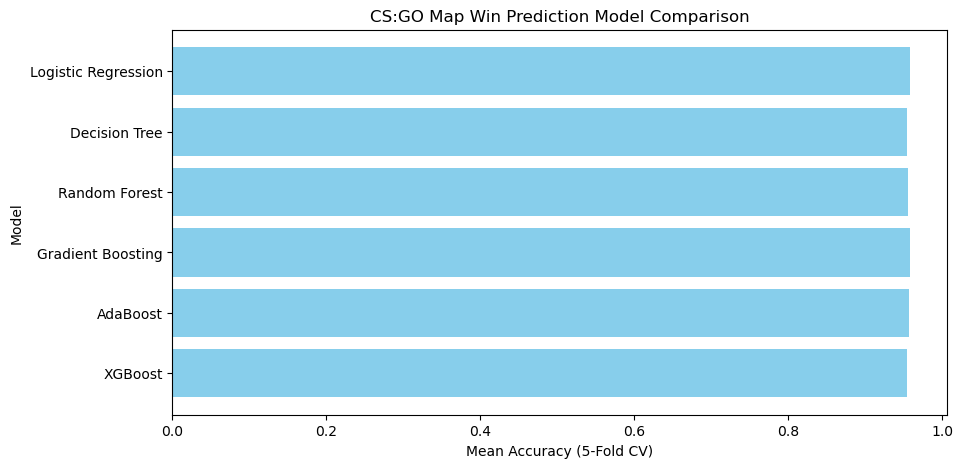

In [20]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib
import numpy as np

# --------------------------
# Split data
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# --------------------------
# Model setup
# --------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# --------------------------
# Evaluate with K-Fold CV
# --------------------------
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("🔍 Evaluating models using 5-Fold Cross Validation...\n")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy', n_jobs=-1)
    results[name] = np.mean(cv_scores)
    print(f"{name:20s} | Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# --------------------------
# Best model
# --------------------------
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

print(f"\n🏆 Best Model: {best_model_name} with Mean Accuracy = {results[best_model_name]:.4f}")

# --------------------------
# Test set performance
# --------------------------
y_pred = best_model.predict(X_test)
print("\n✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --------------------------
# Save best model
# --------------------------
model_path = f"models/csgo_best_{best_model_name.replace(' ', '_')}.pkl"
joblib.dump(best_model, model_path)
print(f"✅ Saved best model to {model_path}")

# --------------------------
# Visualize model leaderboard
# --------------------------
plt.figure(figsize=(10, 5))
plt.barh(list(results.keys()), list(results.values()), color='skyblue')
plt.xlabel('Mean Accuracy (5-Fold CV)')
plt.ylabel('Model')
plt.title('CS:GO Map Win Prediction Model Comparison')
plt.gca().invert_yaxis()
plt.show()
